# Análisis de Complejidad Algorítmica
Comparación de cuatro algoritmos midiendo su tiempo de ejecución real frente a distintos tamaños de entrada.

In [12]:
import time, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')
sys.setrecursionlimit(100000)

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.titlepad': 10
})

## Los cuatro algoritmos
Con base al repositorio dado por el profesor (Algoritmo 1 al Algoritmo 4)

Link: https://github.com/mlopezc/estructuras-datos/tree/main/tarea-corta-1 

In [13]:
def algoritmo1(n):
    contador = 0; suma = 0
    a = 5; b = 7; c = a * b
    for i in range(n):
        for j in range(n):
            contador += 1; suma += i + j
            x = i * j; y = x + 100; z = y / 3
            if x % 2 == 0: suma += 1
            else: suma -= 1
    promedio = suma / (n * n)
    return contador + promedio

def algoritmo2(n):
    total = 0; suma_pares = 0; suma_impares = 0
    a = 10; b = 20; c = a + b
    for i in range(n):
        total += i
        if i % 2 == 0: suma_pares += i
        else: suma_impares += i
        x = i * 2; y = x + 5; z = y / 2
    promedio = total / n
    return promedio + suma_pares + suma_impares

def algoritmo3(n):
    pasos = 0; acumulador = 0
    a = 100; b = 200; c = a + b
    while n > 1:
        acumulador += n
        x = n * 2; y = x - 3; z = y / 5
        if n % 2 == 0: acumulador += 10
        else: acumulador -= 5
        n = n // 2; pasos += 1
    return pasos + acumulador

def algoritmo4(n):
    a = 1; b = 2; c = a + b
    if n <= 1: return n
    x = n * 2; y = x + 10; z = y / 2
    return algoritmo4(n - 1) + algoritmo4(n - 2)

## Medición de tiempos
Cada algoritmo se ejecuta 3 veces por tamaño de entrada y se registra el promedio.

- **Algoritmo 1** se omite para n >= 10,000. Con n = 1,000 ya tarda ~0.15 segundos; escalar a 100,000 implicaría decenas de horas de ejecucion por su crecimiento cuadratico.
- **Algoritmo 4** solo se prueba hasta n = 35. La recursion doble genera un arbol de llamadas de tamanio 2^n, lo que hace inviable cualquier valor mayor.

In [14]:
def medir(func, n, reps=3):
    tiempos = []
    for _ in range(reps):
        t0 = time.perf_counter()
        func(n)
        tiempos.append(time.perf_counter() - t0)
    return round(sum(tiempos) / reps, 8)

sizes_all = [10, 100, 1000, 10000, 100000, 1000000]

s1 = [10, 100, 1000]
t1 = [medir(algoritmo1, n) for n in s1]

s2 = sizes_all
t2 = [medir(algoritmo2, n) for n in s2]

s3 = sizes_all
t3 = [medir(algoritmo3, n) for n in s3]

s4 = [10, 20, 30, 35]
t4 = [medir(algoritmo4, n) for n in s4]

print('Mediciones listas.')

Mediciones listas.


## Tabla de resultados

In [15]:
import pandas as pd

def fmt(t):
    return f'{t:.8f} s' if t is not None else 'omitido'

rows = []
for n in sizes_all:
    row = {'n': f'{n:,}'}
    row['Alg 1  O(n2)']    = fmt(t1[s1.index(n)]) if n in s1 else 'omitido (O(n2) muy lento)'
    row['Alg 2  O(n)']     = fmt(t2[s2.index(n)])
    row['Alg 3  O(log n)'] = fmt(t3[s3.index(n)])
    row['Alg 4  O(2n)']    = 'no aplica' if n > 35 else 'ver abajo'
    rows.append(row)

df = pd.DataFrame(rows)
print(df.to_string(index=False))

print('\nAlgoritmo 4 (valores pequenos):')
df4 = pd.DataFrame([{'n': n, 'tiempo': fmt(t)} for n, t in zip(s4, t4)])
print(df4.to_string(index=False))

        n              Alg 1  O(n2)  Alg 2  O(n) Alg 3  O(log n) Alg 4  O(2n)
       10              0.00001300 s 0.00000250 s    0.00000163 s    ver abajo
      100              0.00118570 s 0.00001010 s    0.00000127 s    no aplica
    1,000              0.14735237 s 0.00011343 s    0.00000247 s    no aplica
   10,000 omitido (O(n2) muy lento) 0.00116000 s    0.00000250 s    no aplica
  100,000 omitido (O(n2) muy lento) 0.01173877 s    0.00000260 s    no aplica
1,000,000 omitido (O(n2) muy lento) 0.12163230 s    0.00000280 s    no aplica

Algoritmo 4 (valores pequenos):
 n       tiempo
10 0.00001443 s
20 0.00175837 s
30 0.22274633 s
35 2.41885200 s


## Graficas por algoritmo
Cada grafica muestra los tiempos medidos junto con la curva teorica correspondiente.

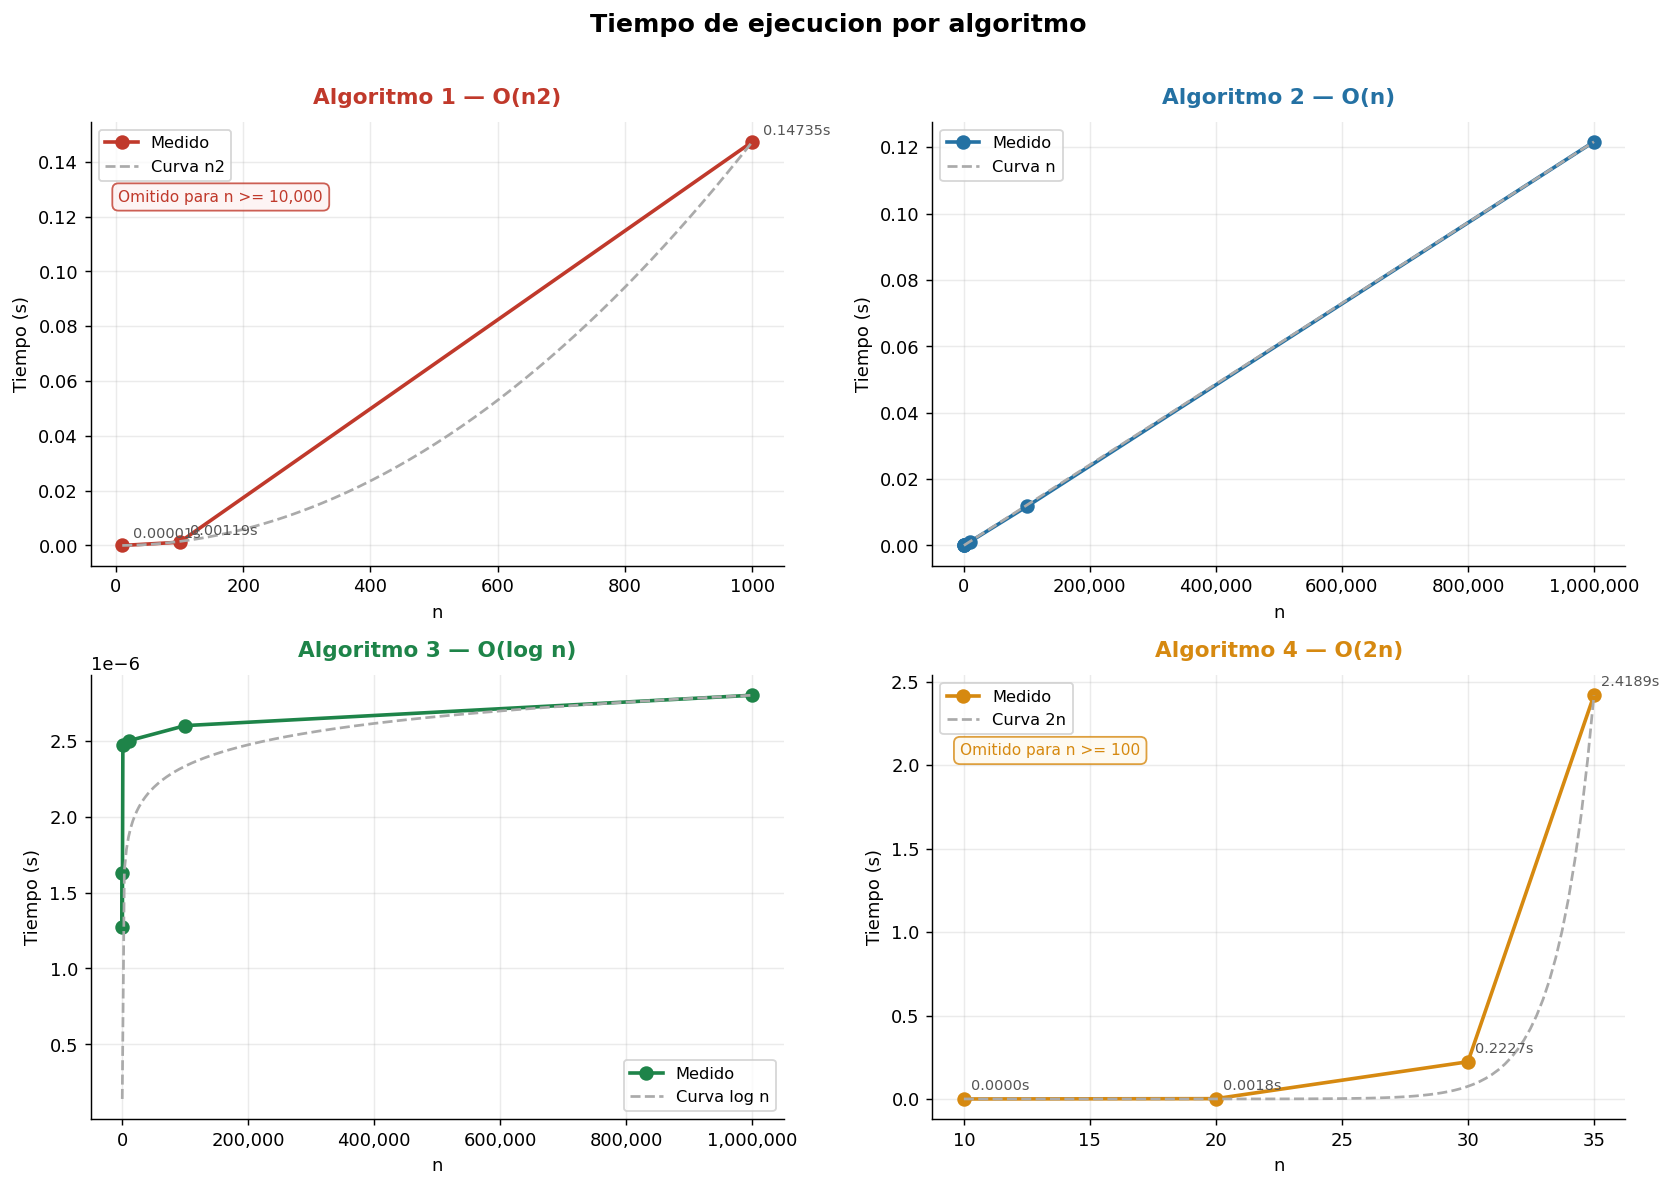

In [16]:
C = ['#c0392b', '#2471a3', '#1e8449', '#d68910']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Tiempo de ejecucion por algoritmo', fontsize=14, fontweight='bold', y=1.01)

# Algoritmo 1 — O(n2)
ax = axes[0][0]
ax.plot(s1, t1, 'o-', color=C[0], lw=2, ms=7, label='Medido')
nf = np.linspace(10, 1000, 200)
ax.plot(nf, (t1[-1] / s1[-1]**2) * nf**2, '--', color='#aaa', lw=1.5, label='Curva n2')
for n, t in zip(s1, t1):
    ax.annotate(f'{t:.5f}s', (n, t), textcoords='offset points', xytext=(6, 4), fontsize=8, color='#555')
ax.set_title('Algoritmo 1 — O(n2)', fontweight='bold', color=C[0])
ax.set_xlabel('n'); ax.set_ylabel('Tiempo (s)')
ax.legend(fontsize=9)
ax.text(0.04, 0.82, 'Omitido para n >= 10,000', transform=ax.transAxes,
        fontsize=8.5, color='#c0392b',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#fdf2f2', edgecolor='#c0392b', alpha=0.8))

# Algoritmo 2 — O(n)
ax = axes[0][1]
ax.plot(s2, t2, 'o-', color=C[1], lw=2, ms=7, label='Medido')
nf2 = np.linspace(10, 1e6, 300)
ax.plot(nf2, (t2[-1] / s2[-1]) * nf2, '--', color='#aaa', lw=1.5, label='Curva n')
ax.set_title('Algoritmo 2 — O(n)', fontweight='bold', color=C[1])
ax.set_xlabel('n'); ax.set_ylabel('Tiempo (s)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.legend(fontsize=9)

# Algoritmo 3 — O(log n)
ax = axes[1][0]
ax.plot(s3, t3, 'o-', color=C[2], lw=2, ms=7, label='Medido')
nf3 = np.linspace(2, 1e6, 300)
ax.plot(nf3, (max(t3) / np.log2(max(s3))) * np.log2(nf3), '--', color='#aaa', lw=1.5, label='Curva log n')
ax.set_title('Algoritmo 3 — O(log n)', fontweight='bold', color=C[2])
ax.set_xlabel('n'); ax.set_ylabel('Tiempo (s)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.legend(fontsize=9)

# Algoritmo 4 — O(2n)
ax = axes[1][1]
ax.plot(s4, t4, 'o-', color=C[3], lw=2, ms=7, label='Medido')
nf4 = np.linspace(10, 35, 100)
ax.plot(nf4, (t4[-1] / 2**s4[-1]) * 2**nf4, '--', color='#aaa', lw=1.5, label='Curva 2n')
for n, t in zip(s4, t4):
    ax.annotate(f'{t:.4f}s', (n, t), textcoords='offset points', xytext=(4, 5), fontsize=8, color='#555')
ax.set_title('Algoritmo 4 — O(2n)', fontweight='bold', color=C[3])
ax.set_xlabel('n'); ax.set_ylabel('Tiempo (s)')
ax.legend(fontsize=9)
ax.text(0.04, 0.82, 'Omitido para n >= 100', transform=ax.transAxes,
        fontsize=8.5, color='#d68910',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#fef9ee', edgecolor='#d68910', alpha=0.8))

plt.tight_layout()
plt.show()

## Comparacion general (escala log-log)
Al poner todos en la misma grafica con escala logaritmica se hace evidente la diferencia de crecimiento entre cada uno.

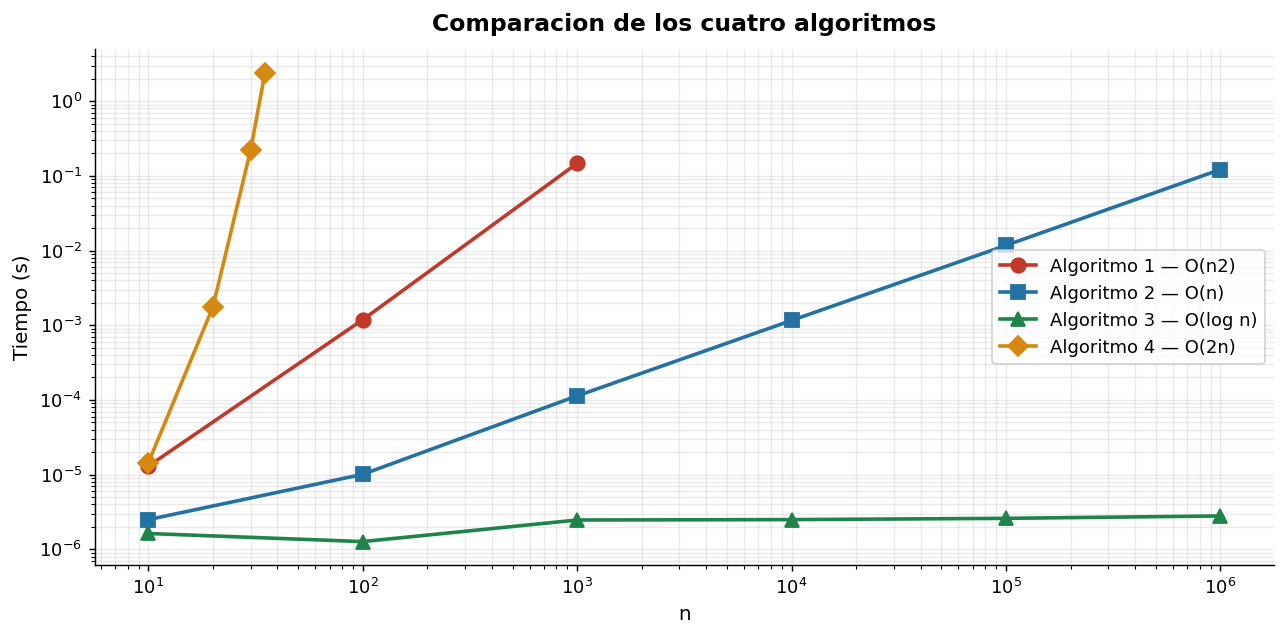

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.loglog(s1, t1, 'o-', color=C[0], lw=2, ms=8, label='Algoritmo 1 — O(n2)')
ax.loglog(s2, t2, 's-', color=C[1], lw=2, ms=8, label='Algoritmo 2 — O(n)')
ax.loglog(s3, t3, '^-', color=C[2], lw=2, ms=8, label='Algoritmo 3 — O(log n)')
ax.loglog(s4, t4, 'D-', color=C[3], lw=2, ms=8, label='Algoritmo 4 — O(2n)')

ax.set_xlabel('n', fontsize=11)
ax.set_ylabel('Tiempo (s)', fontsize=11)
ax.set_title('Comparacion de los cuatro algoritmos', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.25)

plt.tight_layout()
plt.show()

## Conclusiones

| Algoritmo | Complejidad | Por que |
|-----------|-------------|----------|
| Algoritmo 1 | O(n2) | Tiene dos loops anidados: por cada valor de `i` recorre `n` veces `j`. El trabajo crece de forma cuadratica. |
| Algoritmo 2 | O(n) | Un unico loop que recorre los n elementos una sola vez. Crece de forma lineal. |
| Algoritmo 3 | O(log n) | En cada iteracion `n` se divide entre 2 (`n = n // 2`). El numero de pasos es proporcional al logaritmo de n. |
| Algoritmo 4 | O(2n) | Fibonacci recursivo: cada llamada genera dos llamadas mas. El arbol de recursion crece exponencialmente. |

**Por que se omitieron algunos valores:**

El algoritmo 1 con n = 10,000 tendria 100 millones de iteraciones, y con n = 100,000 llegaría a 10,000 millones. A partir de los tiempos medidos, eso equivale a horas de ejecucion, por lo que no es practico probarlo.

El algoritmo 4 crece tan rapido que con n = 40 ya tarda varios segundos, y con n = 100 necesitaria 2^100 operaciones, un numero astronomico que ninguna computadora actual puede procesar en tiempo razonable.

# Parte 2: Analisis Teorico

<div style="display:flex; align-items:center; gap:12px; margin: 28px 0 10px;">
    <span style="background:#c0392b; color:white; font-size:11px; font-weight:700;
                 letter-spacing:2px; text-transform:uppercase; padding:4px 12px;
                 border-radius:4px;">Algoritmo 1</span>
    <h3 style="margin:0; font-size:17px; font-weight:600; color:#1a1a2e;">Conteo → O(n²)</h3>
    <div style="flex:1; height:1px; background:#e8e8e8;"></div>
</div>


In [ ]:
def algoritmo1(n):

    contador = 0          # 1
    suma     = 0          # 1
    a = 5                 # 1
    b = 7                 # 1
    c = a * b             # 1       → 5 operaciones fuera del loop

    for i in range(n):              # ── se repite n veces
        for j in range(n):          # ──── se repite n veces (por cada i)

            contador += 1           # 1
            suma += i + j           # 1
            x = i * j               # 1
            y = x + 100             # 1
            z = y / 3               # 1
            if x % 2 == 0: suma += 1   # 1 (rama verdadera o falsa)
            else:          suma -= 1   # 1

    promedio = suma / (n * n)       # 1
    return contador + promedio      # 1

# ┌────────────────────────────────────────────────┐
# │  Total = 5  +  n × n × 7  +  2                 │
# │        = 7 + 7n²                               │
# │                                                │
# │  Eliminando constantes y coeficientes:         │
# │                                                │
# │              ➤  O(n²)                         │
# └────────────────────────────────────────────────┘

<div style="display:flex; align-items:center; gap:12px; margin: 28px 0 10px;">
    <span style="background:#2471a3; color:white; font-size:11px; font-weight:700;
                 letter-spacing:2px; text-transform:uppercase; padding:4px 12px;
                 border-radius:4px;">Algoritmo 2</span>
    <h3 style="margin:0; font-size:17px; font-weight:600; color:#1a1a2e;">Conteo → O(n)</h3>
    <div style="flex:1; height:1px; background:#e8e8e8;"></div>
</div>

In [ ]:
def algoritmo2(n):

    total        = 0      # 1
    suma_pares   = 0      # 1
    suma_impares = 0      # 1
    a = 10                # 1
    b = 20                # 1
    c = a + b             # 1       → 6 operaciones fuera del loop

    for i in range(n):              # ── se repite n veces

        total += i                  # 1
        if i % 2 == 0:             # 1
            suma_pares   += i      # 1
        else:
            suma_impares += i      # 1
        x = i * 2                  # 1
        y = x + 5                  # 1
        z = y / 2                  # 1       → 7 operaciones por iteración

    promedio = total / n            # 1
    return promedio + suma_pares + suma_impares  # 1

# ┌────────────────────────────────────────────────┐
# │  Total = 6  +  n × 7  +  2                     │
# │        = 8 + 7n                                │
# │                                                │
# │  Eliminando constantes y coeficientes:         │
# │                                                │
# │              ➤  O(n)                          │
# └────────────────────────────────────────────────┘
